<a href="https://colab.research.google.com/github/farrelrassya/PracticalLinearAlgebra/blob/main/13.Chapter13%3AEigendecomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 13: Eigendecomposition

## From *Practical Linear Algebra for Data Science* by Mike X Cohen

---

Eigendecomposition is one of the most powerful and beautiful ideas in all of linear algebra. It takes a square matrix and reveals its fundamental structure: a set of special directions (eigenvectors) and associated scaling factors (eigenvalues) that together tell us *everything* about what the matrix does.

**Why should you care?** Because eigendecomposition is the mathematical engine behind:

- **Principal Components Analysis (PCA)** -- the most widely used dimensionality reduction technique in data science
- **Noise reduction** -- separating signal from noise in measurements
- **Data compression** -- storing images and signals efficiently (JPEG, MP3)
- **Graph analysis** -- identifying influential nodes in social networks
- **Dynamical systems** -- predicting the long-term behavior of physical and economic systems

**The key equation of this chapter:**

$$\mathbf{A}\mathbf{v} = \lambda \mathbf{v}$$

This says: when matrix $\mathbf{A}$ multiplies a special vector $\mathbf{v}$, the result is simply that same vector scaled by a number $\lambda$. The vector $\mathbf{v}$ is an **eigenvector** and the scalar $\lambda$ is its corresponding **eigenvalue**. Finding all such pairs $(\lambda, \mathbf{v})$ is what eigendecomposition is all about.

**Prerequisites:** You should be comfortable with matrix multiplication, determinants (Chapter 8), the null space (Chapter 4), and matrix rank (Chapter 6). We will also use the concept of matrix shifting ($\mathbf{A} + \lambda\mathbf{I}$) from Chapter 5.

**What you will learn:**

- The geometric, statistical, and computational interpretations of eigenvalues and eigenvectors
- How to find eigenvalues via the **characteristic polynomial** and eigenvectors via the **null space**
- How to **diagonalize** a matrix: $\mathbf{A} = \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^{-1}$
- Why **symmetric matrices** are special: orthogonal eigenvectors and real-valued eigenvalues
- The **quadratic form** and **definiteness** -- key concepts for optimization and PCA
- **Generalized eigendecomposition** for simultaneous analysis of two matrices

In [1]:

# Setup: Import required libraries

# Uncomment the next line on Google Colab if scipy is not installed:
# !pip install -q scipy

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh  # for symmetric matrices & generalized eigendecomp
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True, linewidth=100)

print("Libraries loaded successfully.")
print(f"NumPy version: {np.__version__}")

Libraries loaded successfully.
NumPy version: 2.0.2


---
## Eigendecomposition Is Only for Square Matrices

The very first thing to know about eigendecomposition is its **scope**: it applies *only* to square matrices. You cannot eigendecompose a $3 \times 5$ or a $100 \times 7$ matrix. Only an $M \times M$ matrix can be eigendecomposed.

Why? Because the eigenvalue equation $\mathbf{A}\mathbf{v} = \lambda\mathbf{v}$ requires that the matrix-vector product $\mathbf{A}\mathbf{v}$ produces a vector with the **same dimensionality** as $\mathbf{v}$. If $\mathbf{A}$ is $M \times N$ with $M \neq N$, then $\mathbf{A}\mathbf{v}$ is an $M$-vector while $\mathbf{v}$ is an $N$-vector -- they cannot be equal.

Every $M \times M$ matrix has exactly $M$ eigenvalues (counting multiplicities) and $M$ corresponding eigenvectors. So a $2 \times 2$ matrix has $2$ eigenvalue-eigenvector pairs, a $100 \times 100$ matrix has $100$ pairs, and so on.

**What about non-square matrices?** They can be decomposed using the **Singular Value Decomposition (SVD)**, which we will study in Chapter 14. The SVD is closely related to eigendecomposition and, in many ways, is even more powerful.

---
## The Geometric Interpretation: Stretching Without Rotating

The most intuitive way to understand eigenvectors is geometrically. When a matrix multiplies a vector, it generally does two things: **rotates** (changes direction) and **scales** (changes length). But for certain special vectors -- the eigenvectors -- the matrix only scales them, without changing their direction at all.

Think of it this way: imagine you are standing in a field with an arrow painted on the ground. A matrix transformation is like a gust of wind that blows on all the arrows in the field. Most arrows get blown sideways (rotated). But some arrows happen to be aligned with the wind direction, so they only get stretched longer or compressed shorter, without changing where they point. Those special arrows are the eigenvectors.

Mathematically, this is the eigenvalue equation:

$$\mathbf{A}\mathbf{v} = \lambda \mathbf{v}$$

The left side ($\mathbf{A}\mathbf{v}$) is a matrix-vector multiplication -- which in general produces a completely new vector pointing in a new direction. The right side ($\lambda\mathbf{v}$) is a scalar-vector multiplication -- which only stretches or compresses the vector along its *original* direction. The equation says: for this particular vector $\mathbf{v}$, the complex matrix multiplication *acts like* simple scalar multiplication.

**What the eigenvalue tells you:**

| Eigenvalue $\lambda$ | Effect on eigenvector |
|:---|:---|
| $\lambda > 1$ | Stretches the vector (makes it longer) |
| $0 < \lambda < 1$ | Compresses the vector (makes it shorter) |
| $\lambda = 1$ | No change at all -- the vector is invariant! |
| $\lambda = 0$ | Collapses the vector to zero (matrix is singular) |
| $\lambda < 0$ | Flips direction AND scales |

Matrix A:
[[2 1]
 [1 3]]

Eigenvalues:  lambda_1 = 1.3820,  lambda_2 = 3.6180
Eigenvector 1: [-0.8507  0.5257]
Eigenvector 2: [-0.5257 -0.8507]


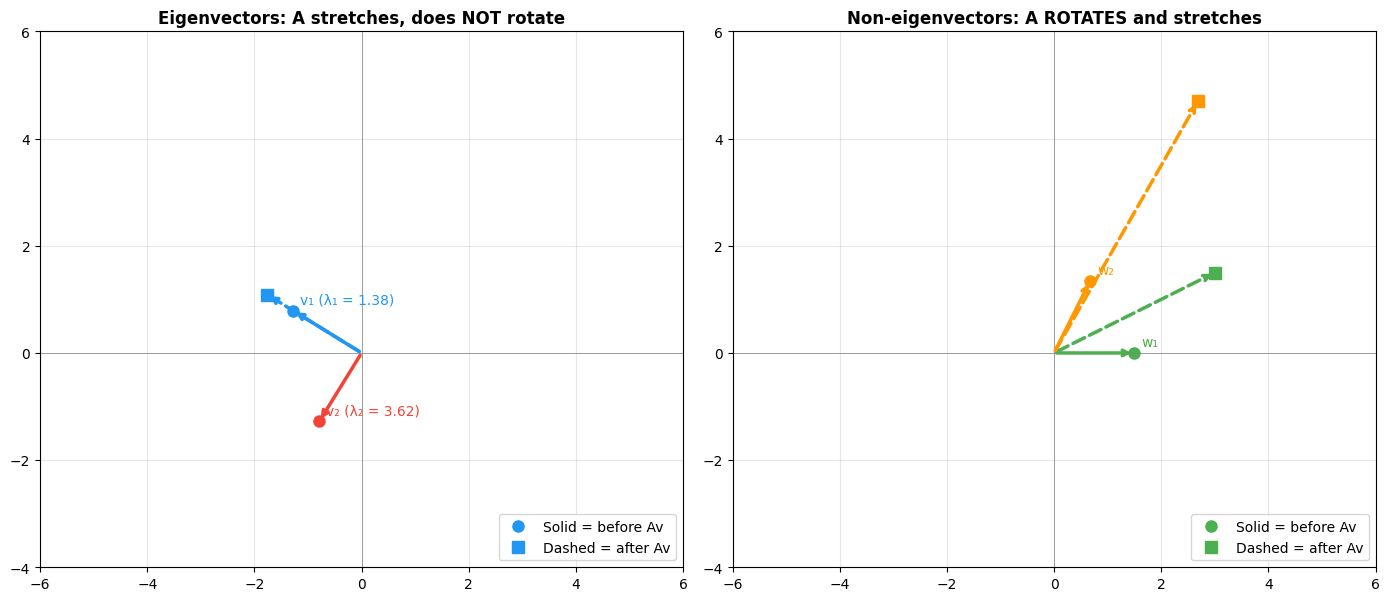

Figure 13-1: Eigenvectors (left) stay aligned; non-eigenvectors (right) rotate.


In [2]:

# Figure 13-1: Geometry of eigenvectors vs non-eigenvectors

A = np.array([[2, 1],
              [1, 3]])

# Compute eigenvalues and eigenvectors
evals, evecs = np.linalg.eig(A)
print(f"Matrix A:\n{A}")
print(f"\nEigenvalues:  lambda_1 = {evals[0]:.4f},  lambda_2 = {evals[1]:.4f}")
print(f"Eigenvector 1: {evecs[:,0].round(4)}")
print(f"Eigenvector 2: {evecs[:,1].round(4)}")

# Scale eigenvectors for visualization
v1 = evecs[:, 0] * 1.5
v2 = evecs[:, 1] * 1.5

# Two non-eigenvectors
w1 = np.array([1.0, 0.0]) * 1.5
w2 = np.array([0.5, 1.0]) / np.linalg.norm([0.5, 1.0]) * 1.5

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Left panel: EIGENVECTORS ---
ax = axes[0]
ax.set_title('Eigenvectors: A stretches, does NOT rotate', fontsize=12, fontweight='bold')
colors = ['#2196F3', '#F44336']
labels = [f'v₁ (λ₁ = {evals[0]:.2f})', f'v₂ (λ₂ = {evals[1]:.2f})']

for vec, col, lbl in zip([v1, v2], colors, labels):
    Avec = A @ vec
    ax.annotate('', xy=vec, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color=col, lw=2.5))
    ax.annotate('', xy=Avec, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color=col, lw=2.5, linestyle='--'))
    ax.plot(*vec, 'o', color=col, markersize=8)
    ax.plot(*Avec, 's', color=col, markersize=8)
    ax.annotate(f'{lbl}', xy=vec, fontsize=10, color=col,
                xytext=(5, 5), textcoords='offset points')

ax.set_xlim(-6, 6)
ax.set_ylim(-4, 6)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.legend(['Solid = before Av', 'Dashed = after Av'], fontsize=10, loc='lower right')

# --- Right panel: NON-EIGENVECTORS ---
ax = axes[1]
ax.set_title('Non-eigenvectors: A ROTATES and stretches', fontsize=12, fontweight='bold')
colors2 = ['#4CAF50', '#FF9800']

for vec, col, lbl in zip([w1, w2], colors2, ['w₁', 'w₂']):
    Avec = A @ vec
    ax.annotate('', xy=vec, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color=col, lw=2.5))
    ax.annotate('', xy=Avec, xytext=[0,0],
                arrowprops=dict(arrowstyle='->', color=col, lw=2.5, linestyle='--'))
    ax.plot(*vec, 'o', color=col, markersize=8)
    ax.plot(*Avec, 's', color=col, markersize=8)
    ax.annotate(f'{lbl}', xy=vec, fontsize=10, color=col,
                xytext=(5, 5), textcoords='offset points')

ax.set_xlim(-6, 6)
ax.set_ylim(-4, 6)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.legend(['Solid = before Av', 'Dashed = after Av'], fontsize=10, loc='lower right')

plt.tight_layout()
plt.show()
print("Figure 13-1: Eigenvectors (left) stay aligned; non-eigenvectors (right) rotate.")

### Reading Figure 13-1

**Left panel (eigenvectors):** The solid arrows show two eigenvectors $\mathbf{v}_1$ and $\mathbf{v}_2$ *before* multiplication by $\mathbf{A}$. The dashed arrows show the result *after* multiplication ($\mathbf{A}\mathbf{v}$). Notice that the dashed arrows point in the **exact same direction** as the solid arrows -- they are only longer. This is the defining property of eigenvectors: the matrix stretches them without rotating them.

$\mathbf{v}_1$ has eigenvalue $\lambda_1 = 1.38$, meaning $\mathbf{A}$ stretches it by a factor of $1.38$. $\mathbf{v}_2$ has eigenvalue $\lambda_2 = 3.62$, meaning $\mathbf{A}$ stretches it by a factor of $3.62$. Both eigenvalues are positive and greater than $1$, so both eigenvectors get longer.

**Right panel (non-eigenvectors):** The solid arrows show two arbitrary (non-eigen) vectors. After multiplication by $\mathbf{A}$, the dashed arrows point in a **different direction** than the originals. The matrix both rotated and scaled these vectors. This is the typical behavior -- most vectors are not eigenvectors.

**The deep insight:** A matrix has infinitely many vectors it could act on, but only $M$ special directions (for an $M \times M$ matrix) where it acts like a simple scalar. Those directions encode the matrix's fundamental geometric "personality."

---
## The Statistical Interpretation: Principal Components Analysis

In data science, the most common application of eigendecomposition is **Principal Components Analysis (PCA)**. PCA answers the question: *What are the most important directions of variation in a multivariate dataset?*

The idea is simple but powerful. Given a dataset with many variables (columns), we compute the **covariance matrix** -- a symmetric matrix that captures how every pair of variables co-varies. Then we eigendecompose this covariance matrix:

$$\mathbf{C} = \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^T$$

The eigenvectors $\mathbf{V}$ are the **principal components** -- the directions in the data space that capture the most variance. The eigenvalues $\boldsymbol{\Lambda}$ tell us **how much variance** each direction captures.

A **scree plot** displays the eigenvalues in descending order. The shape of the scree plot reveals the structure of the data. If the dataset is dominated by one major pattern, the first eigenvalue will be much larger than the rest. If there are several independent patterns, there will be several large eigenvalues before the drop-off.

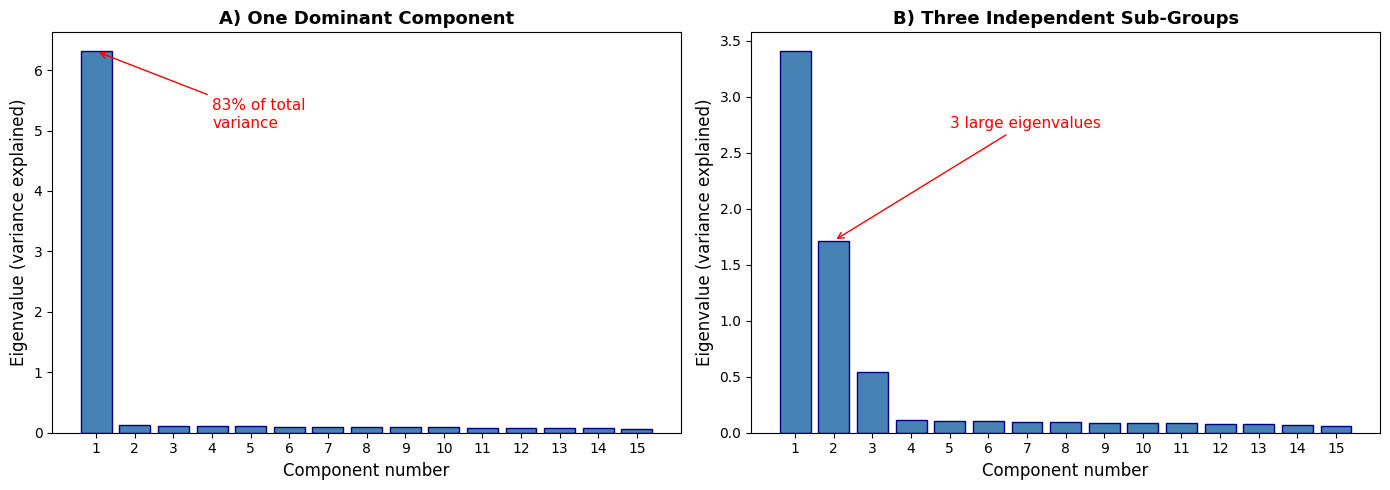

Scenario A: largest eigenvalue = 6.31, captures 83.1% of variance
Scenario B: top 3 eigenvalues capture 84.2% of variance


In [3]:

# Figure 13-2: Simulated scree plots showing different data structures

np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scenario A: One dominant component ---
# Simulate data where all variables are driven by one common factor
n_vars_a = 15
factor = np.random.randn(500, 1)           # one common factor
noise = np.random.randn(500, n_vars_a) * 0.3   # small noise
data_A = factor @ np.random.randn(1, n_vars_a) + noise  # all vars = factor + noise
cov_A = np.cov(data_A, rowvar=False)
evals_A = np.sort(np.linalg.eig(cov_A)[0].real)[::-1]

axes[0].bar(range(1, n_vars_a+1), evals_A, color='steelblue', edgecolor='navy')
axes[0].set_xlabel('Component number', fontsize=12)
axes[0].set_ylabel('Eigenvalue (variance explained)', fontsize=12)
axes[0].set_title('A) One Dominant Component', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(1, n_vars_a+1))

pct_A = evals_A[0] / np.sum(evals_A) * 100
axes[0].annotate(f'{pct_A:.0f}% of total\nvariance', xy=(1, evals_A[0]),
                 xytext=(4, evals_A[0]*0.8), fontsize=11, color='red',
                 arrowprops=dict(arrowstyle='->', color='red'))

# --- Scenario B: Three independent sub-groups ---
n_vars_b = 15
f1 = np.random.randn(500, 1)
f2 = np.random.randn(500, 1)
f3 = np.random.randn(500, 1)
noise_b = np.random.randn(500, n_vars_b) * 0.3
data_B = np.zeros((500, n_vars_b))
data_B[:, 0:5]  = f1 @ np.random.randn(1, 5) + noise_b[:, 0:5]
data_B[:, 5:10] = f2 @ np.random.randn(1, 5) + noise_b[:, 5:10]
data_B[:, 10:15]= f3 @ np.random.randn(1, 5) + noise_b[:, 10:15]
cov_B = np.cov(data_B, rowvar=False)
evals_B = np.sort(np.linalg.eig(cov_B)[0].real)[::-1]

axes[1].bar(range(1, n_vars_b+1), evals_B, color='steelblue', edgecolor='navy')
axes[1].set_xlabel('Component number', fontsize=12)
axes[1].set_ylabel('Eigenvalue (variance explained)', fontsize=12)
axes[1].set_title('B) Three Independent Sub-Groups', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(1, n_vars_b+1))
axes[1].annotate('3 large eigenvalues', xy=(2, evals_B[1]),
                 xytext=(5, evals_B[0]*0.8), fontsize=11, color='red',
                 arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

print(f"Scenario A: largest eigenvalue = {evals_A[0]:.2f}, captures {pct_A:.1f}% of variance")
pct_B = np.sum(evals_B[:3]) / np.sum(evals_B) * 100
print(f"Scenario B: top 3 eigenvalues capture {pct_B:.1f}% of variance")

### Reading Scree Plots

**Scenario A** simulates a dataset where all $15$ variables are driven by a **single common factor** plus small noise. The scree plot shows one dominant eigenvalue towering over the rest. This tells us the data is essentially one-dimensional -- all variables move together. Think of it like $15$ different cryptocurrency prices that all go up and down with Bitcoin.

**Scenario B** simulates a dataset with **three independent sub-groups** of $5$ variables each. The scree plot shows three large eigenvalues, then a sharp drop. This means the data has three independent dimensions of variation. Think of stocks from three different industries (tech, healthcare, energy) that move together within each industry but independently across industries.

The scree plot is one of the most informative single figures in data science. By looking at the "elbow" (where the eigenvalues drop sharply), you can estimate the intrinsic dimensionality of your data. This guides decisions like: *How many principal components should I retain? How much can I compress this data without losing important information?*

We will see full PCA applications in Chapter 15. For now, the key idea is that eigenvalues of the covariance matrix quantify the **importance** of each direction in the data space.

---
## Finding Eigenvalues: The Characteristic Polynomial

Now that we understand *what* eigenvalues and eigenvectors represent, the question is: *how do we find them?*

The derivation starts from the eigenvalue equation and applies a sequence of logical steps -- each building on concepts from earlier chapters. Pay close attention; this is one of the most elegant derivations in linear algebra.

$$\text{Step 1: Start with the eigenvalue equation}$$
$$\mathbf{A}\mathbf{v} = \lambda \mathbf{v}$$

$$\text{Step 2: Move everything to one side}$$
$$\mathbf{A}\mathbf{v} - \lambda\mathbf{v} = \mathbf{0}$$

$$\text{Step 3: Factor out } \mathbf{v} \text{ (requires converting } \lambda \text{ to } \lambda\mathbf{I}\text{)}$$
$$\left(\mathbf{A} - \lambda\mathbf{I}\right)\mathbf{v} = \mathbf{0}$$

**Why $\lambda\mathbf{I}$ instead of just $\lambda$?** Because $\mathbf{A} - \lambda$ is a matrix minus a scalar, which is undefined. We need to subtract a *matrix* from a matrix, so we use $\lambda\mathbf{I}$ (a diagonal matrix with $\lambda$ on the diagonal). This is the **matrix shifting** concept from Chapter 5.

Now, Step 3 says that $\mathbf{v}$ is in the **null space** of $(\mathbf{A} - \lambda\mathbf{I})$. Since we exclude the trivial solution $\mathbf{v} = \mathbf{0}$ (the zero vector is never considered an eigenvector), the matrix $(\mathbf{A} - \lambda\mathbf{I})$ must be **singular** (only singular matrices have non-trivial null spaces). And from Chapter 8, we know that singular matrices have a determinant of zero:

$$\det\left(\mathbf{A} - \lambda\mathbf{I}\right) = 0$$

This equation is called the **characteristic equation**, and the polynomial you get by expanding the determinant is the **characteristic polynomial**. For an $M \times M$ matrix, this is a polynomial of degree $M$ in $\lambda$, so it has exactly $M$ roots (by the Fundamental Theorem of Algebra) -- giving us $M$ eigenvalues.

In [4]:

# Finding eigenvalues: step-by-step for a 2x2 matrix

A = np.array([[1, 2],
              [3, 4]])

print("Matrix A:")
print(A)
print()

# The characteristic polynomial for a 2x2 matrix [a,b; c,d]:
# det(A - lambda*I) = (a - lambda)(d - lambda) - bc = 0
# lambda^2 - (a+d)*lambda + (ad - bc) = 0
# lambda^2 - trace(A)*lambda + det(A) = 0

a, b, c, d = A[0,0], A[0,1], A[1,0], A[1,1]
trace_A = a + d
det_A = a*d - b*c

print("Characteristic polynomial:")
print(f"  lambda^2 - ({a}+{d})*lambda + ({a}*{d} - {b}*{c}) = 0")
print(f"  lambda^2 - {trace_A}*lambda + ({det_A}) = 0")

# Solve using quadratic formula: lambda = (trace +/- sqrt(trace^2 - 4*det)) / 2
discriminant = trace_A**2 - 4*det_A
lambda_1 = (trace_A + np.sqrt(discriminant)) / 2
lambda_2 = (trace_A - np.sqrt(discriminant)) / 2

print(f"\nUsing the quadratic formula:")
print(f"  discriminant = {trace_A}^2 - 4*({det_A}) = {discriminant}")
print(f"  lambda_1 = ({trace_A} + sqrt({discriminant})) / 2 = {lambda_1:.4f}")
print(f"  lambda_2 = ({trace_A} - sqrt({discriminant})) / 2 = {lambda_2:.4f}")

# Verify with NumPy
evals_check = np.linalg.eig(A)[0]
print(f"\nNumPy verification: {evals_check.round(4)}")
print(f"Match? {np.allclose(sorted([lambda_1, lambda_2]), sorted(evals_check))}")

# Verify two beautiful properties:
print(f"\nElegant properties:")
print(f"  Sum of eigenvalues  = {lambda_1 + lambda_2:.4f}  (should equal trace = {trace_A})")
print(f"  Product of eigenvalues = {lambda_1 * lambda_2:.4f}  (should equal det = {det_A})")

Matrix A:
[[1 2]
 [3 4]]

Characteristic polynomial:
  lambda^2 - (1+4)*lambda + (1*4 - 2*3) = 0
  lambda^2 - 5*lambda + (-2) = 0

Using the quadratic formula:
  discriminant = 5^2 - 4*(-2) = 33
  lambda_1 = (5 + sqrt(33)) / 2 = 5.3723
  lambda_2 = (5 - sqrt(33)) / 2 = -0.3723

NumPy verification: [-0.3723  5.3723]
Match? True

Elegant properties:
  Sum of eigenvalues  = 5.0000  (should equal trace = 5)
  Product of eigenvalues = -2.0000  (should equal det = -2)


### The Characteristic Polynomial -- A Deeper Look

For our $2 \times 2$ example, the characteristic polynomial is a quadratic equation that we solve with the quadratic formula. The general form for any $2 \times 2$ matrix is:

$$\det\begin{pmatrix} a - \lambda & b \\ c & d - \lambda \end{pmatrix} = \lambda^2 - \underbrace{(a + d)}_{\text{trace}(\mathbf{A})} \lambda + \underbrace{(ad - bc)}_{\det(\mathbf{A})} = 0$$

This reveals two elegant relationships that hold for **any** square matrix (not just $2 \times 2$):

$$\sum_{i=1}^{M} \lambda_i = \text{trace}(\mathbf{A}) \qquad \text{and} \qquad \prod_{i=1}^{M} \lambda_i = \det(\mathbf{A})$$

The sum of all eigenvalues equals the trace (sum of diagonal elements), and the product of all eigenvalues equals the determinant. These are powerful sanity checks when computing eigenvalues.

**For larger matrices**, the characteristic polynomial has degree $M$, which cannot generally be solved by hand (there is no general formula for degree $\geq 5$ -- this is the Abel-Ruffini theorem). Instead, numerical algorithms like the **QR algorithm** are used. This is what `np.linalg.eig()` does internally.

**The logical chain summarized:**

$$\mathbf{A}\mathbf{v} = \lambda\mathbf{v} \;\Longrightarrow\; (\mathbf{A} - \lambda\mathbf{I})\mathbf{v} = \mathbf{0} \;\Longrightarrow\; \mathbf{v} \in \mathcal{N}(\mathbf{A} - \lambda\mathbf{I}) \;\Longrightarrow\; \det(\mathbf{A} - \lambda\mathbf{I}) = 0$$

Each arrow follows from a concept we learned in earlier chapters: matrix shifting (Ch. 5), null space (Ch. 4), and determinants of singular matrices (Ch. 8).

---
## Finding Eigenvectors: The Null Space of the Shifted Matrix

Once we have the eigenvalues, finding the eigenvectors is conceptually straightforward. Each eigenvector $\mathbf{v}_i$ lives in the **null space** of the matrix shifted by its eigenvalue:

$$\mathbf{v}_i \in \mathcal{N}\left(\mathbf{A} - \lambda_i \mathbf{I}\right)$$

Think of it this way: the eigenvalue is like a key, and the matrix is like a lock. You insert the key ($\lambda_i$) into the matrix (by shifting: $\mathbf{A} - \lambda_i \mathbf{I}$), and the door opens to reveal the eigenvector hiding in the null space.

In [5]:

# Finding eigenvectors via the null space of (A - lambda*I)

A = np.array([[1, 2],
              [2, 1]])

# Step 1: Find eigenvalues
evals = np.linalg.eig(A)[0]
print(f"Matrix A:\n{A}\n")
print(f"Eigenvalues: lambda_1 = {evals[0]:.0f}, lambda_2 = {evals[1]:.0f}\n")

# Step 2: For each eigenvalue, compute (A - lambda*I) and find its null space
for i, lam in enumerate(evals):
    shifted = A - lam * np.eye(2)
    print(f"--- Eigenvalue lambda_{i+1} = {lam:.0f} ---")
    print(f"A - lambda*I =\n{shifted}\n")

    # The null space: find vector v such that (A - lambda*I) @ v = 0
    # By inspection of the shifted matrix:
    print(f"Row 1: {shifted[0,0]:.0f}*v1 + {shifted[0,1]:.0f}*v2 = 0")

    # We can read off the relationship from either row
    if abs(shifted[0,0]) > 1e-10:
        ratio = -shifted[0,1] / shifted[0,0]
        v = np.array([1, ratio])
    else:
        v = np.array([0, 1])

    v_normalized = v / np.linalg.norm(v)
    print(f"Solution: v = {v} (unnormalized)")
    print(f"          v = {v_normalized.round(4)} (unit normalized)")

    # Verify: A @ v should equal lambda * v
    Av = A @ v_normalized
    lv = lam * v_normalized
    print(f"\nVerification: Av = {Av.round(4)}")
    print(f"             λv  = {lv.round(4)}")
    print(f"             Match? {np.allclose(Av, lv)}\n")

# Compare with NumPy's eigenvectors
_, evecs_np = np.linalg.eig(A)
print("NumPy's eigenvectors (columns):")
print(evecs_np.round(4))

Matrix A:
[[1 2]
 [2 1]]

Eigenvalues: lambda_1 = 3, lambda_2 = -1

--- Eigenvalue lambda_1 = 3 ---
A - lambda*I =
[[-2.  2.]
 [ 2. -2.]]

Row 1: -2*v1 + 2*v2 = 0
Solution: v = [1. 1.] (unnormalized)
          v = [0.7071 0.7071] (unit normalized)

Verification: Av = [2.1213 2.1213]
             λv  = [2.1213 2.1213]
             Match? True

--- Eigenvalue lambda_2 = -1 ---
A - lambda*I =
[[2. 2.]
 [2. 2.]]

Row 1: 2*v1 + 2*v2 = 0
Solution: v = [ 1. -1.] (unnormalized)
          v = [ 0.7071 -0.7071] (unit normalized)

Verification: Av = [-0.7071  0.7071]
             λv  = [-0.7071  0.7071]
             Match? True

NumPy's eigenvectors (columns):
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]


### Understanding the Null Space Approach

For the symmetric matrix $\mathbf{A} = \begin{bmatrix} 1 & 2 \\ 2 & 1 \end{bmatrix}$ with eigenvalues $\lambda_1 = 3$ and $\lambda_2 = -1$:

**For $\lambda_1 = 3$:** We shift the matrix by $3$:

$$\mathbf{A} - 3\mathbf{I} = \begin{bmatrix} 1-3 & 2 \\ 2 & 1-3 \end{bmatrix} = \begin{bmatrix} -2 & 2 \\ 2 & -2 \end{bmatrix}$$

The first row says $-2v_1 + 2v_2 = 0$, which means $v_1 = v_2$. So any vector of the form $\begin{bmatrix} t \\ t \end{bmatrix}$ is in the null space. Choosing $t = 1$ and normalizing gives $\mathbf{v}_1 = \frac{1}{\sqrt{2}}\begin{bmatrix} 1 \\ 1 \end{bmatrix}$.

**For $\lambda_2 = -1$:** We shift by $-1$:

$$\mathbf{A} - (-1)\mathbf{I} = \begin{bmatrix} 2 & 2 \\ 2 & 2 \end{bmatrix}$$

The first row says $2v_1 + 2v_2 = 0$, meaning $v_1 = -v_2$. The eigenvector is $\mathbf{v}_2 = \frac{1}{\sqrt{2}}\begin{bmatrix} -1 \\ 1 \end{bmatrix}$.

Notice that $\mathbf{v}_1 \cdot \mathbf{v}_2 = \frac{1}{2}((-1)(1) + (1)(1)) = 0$ -- the eigenvectors are **orthogonal**! This is no coincidence: it happens because $\mathbf{A}$ is symmetric. We will prove this property later in the chapter.

---
## Computing Eigendecomposition in Python

In practice, we use `np.linalg.eig()` rather than computing eigenvalues and eigenvectors by hand. The function returns both the eigenvalues (as a vector) and the eigenvectors (as columns of a matrix).

In [6]:

# Eigendecomposition in Python: the practical way

A = np.array([[1, 2],
              [3, 4]])

# np.linalg.eig returns (eigenvalues, eigenvectors_matrix)
evals, evecs = np.linalg.eig(A)

print(f"Matrix A:\n{A}\n")
print(f"Eigenvalues: {evals}")
print(f"\nEigenvectors (in COLUMNS of the matrix):")
print(f"{evecs}")

print(f"\n--- CRITICAL: Eigenvectors are in COLUMNS, not rows! ---")
print(f"Eigenvector 1 (column 0): {evecs[:, 0]}")
print(f"Eigenvector 2 (column 1): {evecs[:, 1]}")
print(f"\n--- NOT these (rows) -- this would be WRONG: ---")
print(f"Row 0 (NOT an eigenvector): {evecs[0, :]}")
print(f"Row 1 (NOT an eigenvector): {evecs[1, :]}")

# Verify the eigenvalue equation: A @ v = lambda * v
print("\n--- Verification ---")
for i in range(len(evals)):
    Av  = A @ evecs[:, i]
    lam_v = evals[i] * evecs[:, i]
    print(f"lambda_{i+1} = {evals[i]:.4f}")
    print(f"  A @ v_{i+1}      = {Av.round(6)}")
    print(f"  lambda_{i+1} * v_{i+1} = {lam_v.round(6)}")
    print(f"  Match? {np.allclose(Av, lam_v)}\n")

Matrix A:
[[1 2]
 [3 4]]

Eigenvalues: [-0.3723  5.3723]

Eigenvectors (in COLUMNS of the matrix):
[[-0.8246 -0.416 ]
 [ 0.5658 -0.9094]]

--- CRITICAL: Eigenvectors are in COLUMNS, not rows! ---
Eigenvector 1 (column 0): [-0.8246  0.5658]
Eigenvector 2 (column 1): [-0.416  -0.9094]

--- NOT these (rows) -- this would be WRONG: ---
Row 0 (NOT an eigenvector): [-0.8246 -0.416 ]
Row 1 (NOT an eigenvector): [ 0.5658 -0.9094]

--- Verification ---
lambda_1 = -0.3723
  A @ v_1      = [ 0.307  -0.2106]
  lambda_1 * v_1 = [ 0.307  -0.2106]
  Match? True

lambda_2 = 5.3723
  A @ v_2      = [-2.2347 -4.8854]
  lambda_2 * v_2 = [-2.2347 -4.8854]
  Match? True



### The Column Convention -- Do Not Forget This!

The single most common mistake when working with eigenvectors in code is confusing **rows** and **columns**. NumPy stores eigenvectors as **columns** of the matrix, not rows. With square matrices, you will not get a shape error if you accidentally use rows -- you will just get wrong answers silently.

Always access eigenvector $i$ as `evecs[:, i]` (a column slice), never as `evecs[i, :]` (a row slice).

This convention follows from the standard mathematical notation where $\mathbf{V} = [\mathbf{v}_1 \;|\; \mathbf{v}_2 \;|\; \cdots \;|\; \mathbf{v}_M]$ -- each eigenvector occupies a column of $\mathbf{V}$.

---
## Sign and Scale Indeterminacy of Eigenvectors

An important subtlety: eigenvectors are not unique. If $\mathbf{v}$ is an eigenvector of $\mathbf{A}$, then $\alpha\mathbf{v}$ is *also* an eigenvector for any nonzero scalar $\alpha$. Here is the proof:

$$\mathbf{A}(\alpha\mathbf{v}) = \alpha(\mathbf{A}\mathbf{v}) = \alpha(\lambda\mathbf{v}) = \lambda(\alpha\mathbf{v})$$

This means:

- $\begin{bmatrix} 1 \\ 1 \end{bmatrix}$, $\begin{bmatrix} 2 \\ 2 \end{bmatrix}$, $\begin{bmatrix} -3 \\ -3 \end{bmatrix}$, and $\begin{bmatrix} 0.5 \\ 0.5 \end{bmatrix}$ are all valid eigenvectors (they all point along the same line).
- The **direction** of an eigenvector matters, but its **magnitude** does not.
- The **sign** is also arbitrary: $\mathbf{v}$ and $-\mathbf{v}$ are both valid.

By convention, eigenvectors are usually **unit normalized** (magnitude $= 1$), which is what `np.linalg.eig` returns. But the sign can vary between software versions, programming languages, and even different runs. This is not a bug -- it is a fundamental mathematical property.

In [7]:

# Demonstrating sign and scale indeterminacy

A = np.array([[1, 2],
              [2, 1]])

evals, evecs = np.linalg.eig(A)
v1 = evecs[:, 0]

print(f"Standard eigenvector v1 = {v1.round(4)}")
print(f"  Norm: {np.linalg.norm(v1):.4f}")
print()

# All of these are valid eigenvectors:
scalars = [2, -1, 0.5, -3.7, 100]
for alpha in scalars:
    scaled_v = alpha * v1
    Av = A @ scaled_v
    lam_v = evals[0] * scaled_v
    print(f"  alpha = {alpha:6.1f}:  alpha*v1 = {scaled_v.round(4)}, "
          f"  A@(alpha*v1) = {Av.round(4)}, "
          f"  lambda*(alpha*v1) = {lam_v.round(4)}, "
          f"  Equal? {np.allclose(Av, lam_v)}")

print(f"\nAll {len(scalars)} scaled versions satisfy the eigenvalue equation!")
print("Direction matters. Magnitude and sign do not.")

Standard eigenvector v1 = [0.7071 0.7071]
  Norm: 1.0000

  alpha =    2.0:  alpha*v1 = [1.4142 1.4142],   A@(alpha*v1) = [4.2426 4.2426],   lambda*(alpha*v1) = [4.2426 4.2426],   Equal? True
  alpha =   -1.0:  alpha*v1 = [-0.7071 -0.7071],   A@(alpha*v1) = [-2.1213 -2.1213],   lambda*(alpha*v1) = [-2.1213 -2.1213],   Equal? True
  alpha =    0.5:  alpha*v1 = [0.3536 0.3536],   A@(alpha*v1) = [1.0607 1.0607],   lambda*(alpha*v1) = [1.0607 1.0607],   Equal? True
  alpha =   -3.7:  alpha*v1 = [-2.6163 -2.6163],   A@(alpha*v1) = [-7.8489 -7.8489],   lambda*(alpha*v1) = [-7.8489 -7.8489],   Equal? True
  alpha =  100.0:  alpha*v1 = [70.7107 70.7107],   A@(alpha*v1) = [212.132 212.132],   lambda*(alpha*v1) = [212.132 212.132],   Equal? True

All 5 scaled versions satisfy the eigenvalue equation!
Direction matters. Magnitude and sign do not.


### Why Indeterminacy Is Not a Problem

You might worry: if eigenvectors are not unique, how can they be useful? The answer is that applications of eigendecomposition (PCA, spectral clustering, etc.) depend on the **direction** of the eigenvectors (which subspace they span), not on their specific scaling or sign.

For example, in PCA, the first principal component defines a *line* through the data -- whether you label the positive end "left" or "right" does not change the analysis. In some applications, there are conventions for choosing the sign (e.g., making the largest element positive), but these are just conventions for consistency.

---
## Diagonalizing a Square Matrix

Each eigenvalue-eigenvector pair gives us one equation: $\mathbf{A}\mathbf{v}_i = \lambda_i \mathbf{v}_i$. For an $M \times M$ matrix, we have $M$ such equations. We can combine them all into a single, elegant matrix equation.

Collect all eigenvectors as columns of a matrix $\mathbf{V}$ and all eigenvalues in a diagonal matrix $\boldsymbol{\Lambda}$:

$$\mathbf{A} \underbrace{\begin{bmatrix} | & | & & | \\ \mathbf{v}_1 & \mathbf{v}_2 & \cdots & \mathbf{v}_M \\ | & | & & | \end{bmatrix}}_{\mathbf{V}} = \underbrace{\begin{bmatrix} | & | & & | \\ \mathbf{v}_1 & \mathbf{v}_2 & \cdots & \mathbf{v}_M \\ | & | & & | \end{bmatrix}}_{\mathbf{V}} \underbrace{\begin{bmatrix} \lambda_1 & 0 & \cdots & 0 \\ 0 & \lambda_2 & \cdots & 0 \\ \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & \cdots & \lambda_M \end{bmatrix}}_{\boldsymbol{\Lambda}}$$

This gives us: $\mathbf{A}\mathbf{V} = \mathbf{V}\boldsymbol{\Lambda}$

The magic of the diagonal matrix on the right: when $\mathbf{V}$ is postmultiplied by $\boldsymbol{\Lambda}$, each **column** of $\mathbf{V}$ gets scaled by the corresponding diagonal entry. Column $i$ of $\mathbf{V}$ is multiplied by $\lambda_i$ -- exactly what the eigenvalue equation says!

Rearranging (assuming $\mathbf{V}$ is invertible):

$$\boxed{\mathbf{A} = \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^{-1}}$$

This is called the **eigendecomposition** or **diagonalization** of $\mathbf{A}$. It decomposes the matrix into three factors: a change-of-basis ($\mathbf{V}^{-1}$), a simple diagonal scaling ($\boldsymbol{\Lambda}$), and the inverse change-of-basis ($\mathbf{V}$).

**Intuition:** In the standard basis, $\mathbf{A}$ is a complex matrix with entries everywhere. But from the perspective of the eigenvectors basis, $\mathbf{A}$ is simply a diagonal matrix -- all it does is scale each axis independently. The eigendecomposition reveals the "natural coordinate system" in which the matrix has the simplest possible form.

In [8]:

# Diagonalization: AV = V * Lambda

A = np.array([[4, 2],
              [1, 3]])

evals, evecs = np.linalg.eig(A)

print(f"Matrix A:\n{A}\n")
print(f"Eigenvalues: {evals}")
print(f"Eigenvectors matrix V:\n{evecs.round(4)}\n")

# Create diagonal matrix Lambda
Lambda = np.diag(evals)
print(f"Diagonal matrix Lambda:\n{Lambda.round(4)}\n")

# Verify: A @ V == V @ Lambda ?
AV = A @ evecs
VL = evecs @ Lambda
print("Verification: A @ V =")
print(AV.round(4))
print("\n             V @ Lambda =")
print(VL.round(4))
print(f"\nEqual? {np.allclose(AV, VL)}")

# Reconstruct A from V, Lambda, V_inv
V_inv = np.linalg.inv(evecs)
A_reconstructed = evecs @ Lambda @ V_inv

print(f"\n--- Reconstruction: A = V @ Lambda @ V^{{-1}} ---")
print(f"V @ Lambda @ V^(-1) =\n{A_reconstructed.round(4)}")
print(f"Original A =\n{A}")
print(f"Match? {np.allclose(A, A_reconstructed)}")

Matrix A:
[[4 2]
 [1 3]]

Eigenvalues: [5. 2.]
Eigenvectors matrix V:
[[ 0.8944 -0.7071]
 [ 0.4472  0.7071]]

Diagonal matrix Lambda:
[[5. 0.]
 [0. 2.]]

Verification: A @ V =
[[ 4.4721 -1.4142]
 [ 2.2361  1.4142]]

             V @ Lambda =
[[ 4.4721 -1.4142]
 [ 2.2361  1.4142]]

Equal? True

--- Reconstruction: A = V @ Lambda @ V^{-1} ---
V @ Lambda @ V^(-1) =
[[4. 2.]
 [1. 3.]]
Original A =
[[4 2]
 [1 3]]
Match? True


### Three Equivalent Forms of Diagonalization

Starting from $\mathbf{A}\mathbf{V} = \mathbf{V}\boldsymbol{\Lambda}$, we can rearrange to get three equivalent equations:

$$\mathbf{A}\mathbf{V} = \mathbf{V}\boldsymbol{\Lambda} \qquad \Longleftrightarrow \qquad \mathbf{A} = \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^{-1} \qquad \Longleftrightarrow \qquad \boldsymbol{\Lambda} = \mathbf{V}^{-1}\mathbf{A}\mathbf{V}$$

The second form ($\mathbf{A} = \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^{-1}$) decomposes the matrix into its eigenstructure. The third form ($\boldsymbol{\Lambda} = \mathbf{V}^{-1}\mathbf{A}\mathbf{V}$) shows that $\mathbf{A}$ becomes **diagonal** when we transform into the eigenvector basis. This is why the process is called "diagonalization" -- the matrix $\mathbf{A}$ is dense and complicated in the standard basis, but diagonal and trivial in its eigenbasis.

**Connection to basis vectors (Chapter 7):** The eigenvectors form a new coordinate system. $\mathbf{V}^{-1}$ converts a vector from the standard basis to the eigenvector basis. In this new coordinate system, the matrix $\mathbf{A}$ is diagonal -- it simply stretches each axis by the corresponding eigenvalue. Then $\mathbf{V}$ converts back to the standard basis. Matrix multiplication by $\mathbf{A}$ is fundamentally just stretching along $M$ independent directions.

---
## The Special Awesomeness of Symmetric Matrices

Symmetric matrices ($\mathbf{A} = \mathbf{A}^T$) have two remarkable properties for eigendecomposition that make them the "rock stars" of linear algebra in data science:

**Property 1:** All eigenvectors are **pairwise orthogonal** (perpendicular).

**Property 2:** All eigenvalues are **real-valued** (no complex numbers).

These properties are not shared by general (non-symmetric) matrices. They make symmetric matrices much easier to work with and give their eigendecomposition a beautiful geometric structure.

In [9]:

# Symmetric matrices: orthogonal eigenvectors

np.random.seed(42)

# Create a random symmetric matrix: A = R^T @ R
R = np.random.randint(-3, 4, (3, 3))
A = R.T @ R
print(f"Symmetric matrix A = R^T @ R:")
print(A)
print(f"\nIs symmetric? {np.allclose(A, A.T)}")

# Eigendecomposition
evals, evecs = np.linalg.eig(A)
print(f"\nEigenvalues: {evals.round(4)}")
print(f"\nEigenvectors (columns of V):")
print(evecs.round(4))

# Check all pairwise dot products
print("\n--- Pairwise orthogonality check ---")
for i in range(3):
    for j in range(i+1, 3):
        dot = np.dot(evecs[:, i], evecs[:, j])
        print(f"  v{i+1} . v{j+1} = {dot:.2e}  {'(orthogonal!)' if abs(dot) < 1e-10 else ''}")

# Check that V^T @ V = I (orthogonal matrix)
VtV = evecs.T @ evecs
print(f"\nV^T @ V (should be identity):")
print(VtV.round(4))
print(f"\nIs V an orthogonal matrix? {np.allclose(VtV, np.eye(3))}")

# This means V^{-1} = V^T for symmetric matrices!
print(f"\n--- Huge practical implication ---")
print(f"V^(-1) equals V^T? {np.allclose(np.linalg.inv(evecs), evecs.T)}")
print("For symmetric matrices: A = V @ Lambda @ V^T  (no need to compute inverse!)")

Symmetric matrix A = R^T @ R:
[[19  0  4]
 [ 0 10 -7]
 [ 4 -7  6]]

Is symmetric? True

Eigenvalues: [ 0.1671 20.603  14.2299]

Eigenvectors (columns of V):
[[ 0.1705 -0.9015 -0.3979]
 [-0.5715  0.2385 -0.7852]
 [-0.8027 -0.3612  0.4745]]

--- Pairwise orthogonality check ---
  v1 . v2 = -5.55e-17  (orthogonal!)
  v1 . v3 = 2.22e-16  (orthogonal!)
  v2 . v3 = 5.00e-16  (orthogonal!)

V^T @ V (should be identity):
[[ 1. -0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]

Is V an orthogonal matrix? True

--- Huge practical implication ---
V^(-1) equals V^T? True
For symmetric matrices: A = V @ Lambda @ V^T  (no need to compute inverse!)


### Why Orthogonal Eigenvectors Matter

When the eigenvectors are orthogonal and unit-normalized, the eigenvector matrix $\mathbf{V}$ is an **orthogonal matrix**, meaning $\mathbf{V}^T\mathbf{V} = \mathbf{I}$ and therefore $\mathbf{V}^{-1} = \mathbf{V}^T$.

This simplifies the diagonalization formula beautifully:

$$\mathbf{A} = \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^{-1} \;\;\Longrightarrow\;\; \mathbf{A} = \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^T$$

**Why is this such a big deal?**

Computing a matrix inverse is expensive ($O(M^3)$ operations) and numerically unstable. A transpose is essentially free -- you just swap row and column indices. For symmetric matrices, we never need to compute $\mathbf{V}^{-1}$; we simply use $\mathbf{V}^T$. This is faster, more stable, and more memory-efficient.

In data science, the matrices we eigendecompose are almost always **covariance matrices**, which are symmetric by definition ($\mathbf{C} = \mathbf{X}^T\mathbf{X}$). So this simplification applies to virtually every PCA computation you will ever run.

**The eigh function:** If you know your matrix is symmetric, use `np.linalg.eigh()` instead of `np.linalg.eig()`. The `h` stands for "Hermitian" (the complex generalization of symmetric). `eigh` is faster, more numerically stable, and returns eigenvalues sorted in ascending order.

### Proof: Eigenvectors of Symmetric Matrices Are Orthogonal

This is one of the most important proofs in applied linear algebra. Let us walk through it step by step.

**Given:** A symmetric matrix $\mathbf{A} = \mathbf{A}^T$ with two distinct eigenvalues $\lambda_1 \neq \lambda_2$ and their eigenvectors $\mathbf{v}_1$ and $\mathbf{v}_2$.

**Goal:** Show that $\mathbf{v}_1^T \mathbf{v}_2 = 0$ (orthogonal).

**Step 1:** Start from the eigenvalue equation for $\mathbf{v}_1$ and left-multiply by $\mathbf{v}_2^T$:

$$\lambda_1 \mathbf{v}_1^T \mathbf{v}_2 = (\mathbf{A}\mathbf{v}_1)^T \mathbf{v}_2 = \mathbf{v}_1^T \mathbf{A}^T \mathbf{v}_2$$

**Step 2:** Because $\mathbf{A}$ is symmetric ($\mathbf{A}^T = \mathbf{A}$), we can replace $\mathbf{A}^T$ with $\mathbf{A}$, and then use the eigenvalue equation for $\mathbf{v}_2$:

$$\mathbf{v}_1^T \mathbf{A}^T \mathbf{v}_2 = \mathbf{v}_1^T \mathbf{A} \mathbf{v}_2 = \mathbf{v}_1^T (\lambda_2 \mathbf{v}_2) = \lambda_2 \mathbf{v}_1^T \mathbf{v}_2$$

**Step 3:** Combine Steps 1 and 2:

$$\lambda_1 \mathbf{v}_1^T \mathbf{v}_2 = \lambda_2 \mathbf{v}_1^T \mathbf{v}_2$$

$$\Rightarrow \quad (\lambda_1 - \lambda_2)\, \mathbf{v}_1^T \mathbf{v}_2 = 0$$

Since $\lambda_1 \neq \lambda_2$, the factor $(\lambda_1 - \lambda_2) \neq 0$. Therefore, $\mathbf{v}_1^T \mathbf{v}_2 = 0$. $\blacksquare$

**The key step** that makes this proof work is the substitution $\mathbf{A}^T = \mathbf{A}$ in Step 2. For a non-symmetric matrix, $\mathbf{A}^T \neq \mathbf{A}$, and the chain of equalities breaks. This is why non-symmetric matrices do *not* have orthogonal eigenvectors in general.

---
## Real-Valued Eigenvalues of Symmetric Matrices

The second special property: symmetric matrices always have **real-valued** eigenvalues. General (non-symmetric) matrices can have complex-valued eigenvalues, even if the matrix itself contains only real numbers.

In [10]:

# Real vs. complex eigenvalues

# A non-symmetric matrix can have complex eigenvalues
A_nonsym = np.array([[-3, -3, 0],
                     [ 3, -2, 3],
                     [ 0,  1, 2]])

print("Non-symmetric matrix A:")
print(A_nonsym)
print(f"Symmetric? {np.allclose(A_nonsym, A_nonsym.T)}")

evals_nonsym = np.linalg.eig(A_nonsym)[0]
print(f"\nEigenvalues: {evals_nonsym}")
print(f"Are they real? {np.all(np.isreal(evals_nonsym))}")
print(f"Notice: complex eigenvalues come in conjugate pairs!")
print(f"  lambda_1 = {evals_nonsym[0]:.4f}")
print(f"  lambda_2 = {evals_nonsym[1]:.4f}  (conjugate of lambda_1)")
print(f"  lambda_3 = {evals_nonsym[2]:.4f}  (real)")

# Make it symmetric and eigenvalues become real
A_sym = np.array([[-3, -3, 0],
                  [-3, -2, 1],
                  [ 0,  1, 2]])

print(f"\n{'='*50}")
print(f"Symmetric version:")
print(A_sym)
print(f"Symmetric? {np.allclose(A_sym, A_sym.T)}")

evals_sym = np.linalg.eig(A_sym)[0]
print(f"\nEigenvalues: {evals_sym.round(4)}")
print(f"Are they all real? {np.all(np.isreal(evals_sym))}")

# Verify with many random symmetric matrices
print("\n--- Testing 1000 random symmetric matrices ---")
all_real = True
for _ in range(1000):
    R = np.random.randn(5, 5)
    S = R.T @ R  # guaranteed symmetric
    ev = np.linalg.eig(S)[0]
    if not np.all(np.isreal(ev)):
        all_real = False
        break
print(f"All 1000 symmetric matrices had real eigenvalues? {all_real}")

Non-symmetric matrix A:
[[-3 -3  0]
 [ 3 -2  3]
 [ 0  1  2]]
Symmetric? False

Eigenvalues: [-2.7447+2.8517j -2.7447-2.8517j  2.4895+0.j    ]
Are they real? False
Notice: complex eigenvalues come in conjugate pairs!
  lambda_1 = -2.7447+2.8517j
  lambda_2 = -2.7447-2.8517j  (conjugate of lambda_1)
  lambda_3 = 2.4895+0.0000j  (real)

Symmetric version:
[[-3 -3  0]
 [-3 -2  1]
 [ 0  1  2]]
Symmetric? True

Eigenvalues: [-5.5971  0.2261  2.371 ]
Are they all real? True

--- Testing 1000 random symmetric matrices ---
All 1000 symmetric matrices had real eigenvalues? True


### Why Real Eigenvalues Matter in Practice

Complex eigenvalues are mathematically valid but inconvenient for data science. When you run PCA on a covariance matrix, you want the eigenvalues to represent **variance** -- a real, positive quantity. Complex numbers do not have a natural ordering (you cannot say $3 + 2i > 1 - 4i$), so concepts like "the largest eigenvalue" or "sort eigenvalues in descending order" would not make sense with complex eigenvalues.

Fortunately, covariance matrices are always symmetric, so their eigenvalues are always real. If you ever see complex eigenvalues when working with what should be a covariance matrix, it almost certainly indicates a bug in your code.

**Complex conjugate pairs:** When a real-valued non-symmetric matrix has complex eigenvalues, they always come in conjugate pairs: if $\lambda = a + bi$ is an eigenvalue, then $\bar{\lambda} = a - bi$ is also an eigenvalue. Their corresponding eigenvectors are also conjugate pairs. An $M \times M$ real matrix with odd $M$ must have at least one real eigenvalue (since complex pairs account for an even number).

**Practical tip:** Use `np.linalg.eigh()` for symmetric matrices -- it is faster and guarantees real-valued output.

---
## Eigendecomposition of Singular Matrices

A common misconception: students sometimes think that singular (non-invertible) matrices cannot be eigendecomposed. This is **completely wrong**. Eigendecomposition works perfectly well on singular matrices.

The special property is that at least one eigenvalue is guaranteed to be **zero**. Think about why: a singular matrix has a non-trivial null space, meaning there exists a nonzero $\mathbf{v}$ such that $\mathbf{A}\mathbf{v} = \mathbf{0}$. Comparing with $\mathbf{A}\mathbf{v} = \lambda\mathbf{v}$, we see that $\lambda = 0$ and $\mathbf{v}$ is the null space vector.

$$\mathbf{A}\mathbf{v} = \mathbf{0} = 0 \cdot \mathbf{v} \;\;\Longrightarrow\;\; \lambda = 0$$

Conversely, if all eigenvalues are nonzero, the matrix must be full-rank (invertible).

In [11]:

# Eigendecomposition of a singular matrix

A = np.array([[1, 4, 7],
              [2, 5, 8],
              [3, 6, 9]])

print(f"Matrix A:\n{A}")
print(f"\nRank: {np.linalg.matrix_rank(A)}  (out of 3 -- so it is singular)")
print(f"Determinant: {np.linalg.det(A):.6f}")

evals, evecs = np.linalg.eig(A)
print(f"\nEigenvalues: {evals.round(4)}")
print(f"\nEigenvectors (columns):")
print(evecs.round(4))

# The eigenvector for lambda = 0 spans the null space
zero_idx = np.argmin(np.abs(evals))
null_vec = evecs[:, zero_idx]
print(f"\nEigenvector for lambda ≈ 0: {null_vec.round(4)}")
print(f"A @ v = {(A @ null_vec).round(10)}  (should be zero vector)")

# Verify: null space vector is the combination that gives zeros
print(f"\nInterpretation: columns of A are linearly dependent.")
print(f"  Col3 = Col1 + Col2? Let's check: {A[:,0] + A[:,1]} vs {A[:,2]}")
print(f"  Col3 - Col2 - Col1 = {A[:,2] - A[:,1] - A[:,0]}")
print(f"  Not exactly, but col3 = 2*col2 - col1:")
print(f"  2*col2 - col1 = {2*A[:,1] - A[:,0]} vs col3 = {A[:,2]}")

# Summary table
print(f"\n{'='*50}")
print(f"SUMMARY: Rank vs Eigenvalues")
print(f"  Matrix size: 3x3")
print(f"  Rank: {np.linalg.matrix_rank(A)}")
print(f"  Number of nonzero eigenvalues: {np.sum(np.abs(evals) > 1e-10)}")
print(f"  Number of zero eigenvalues: {np.sum(np.abs(evals) < 1e-10)}")
print(f"  Rule: A singular matrix has at least one zero eigenvalue.")

Matrix A:
[[1 4 7]
 [2 5 8]
 [3 6 9]]

Rank: 2  (out of 3 -- so it is singular)
Determinant: 0.000000

Eigenvalues: [16.1168 -1.1168 -0.    ]

Eigenvectors (columns):
[[-0.4645 -0.8829  0.4082]
 [-0.5708 -0.2395 -0.8165]
 [-0.677   0.4039  0.4082]]

Eigenvector for lambda ≈ 0: [ 0.4082 -0.8165  0.4082]
A @ v = [ 0. -0. -0.]  (should be zero vector)

Interpretation: columns of A are linearly dependent.
  Col3 = Col1 + Col2? Let's check: [5 7 9] vs [7 8 9]
  Col3 - Col2 - Col1 = [2 1 0]
  Not exactly, but col3 = 2*col2 - col1:
  2*col2 - col1 = [7 8 9] vs col3 = [7 8 9]

SUMMARY: Rank vs Eigenvalues
  Matrix size: 3x3
  Rank: 2
  Number of nonzero eigenvalues: 2
  Number of zero eigenvalues: 1
  Rule: A singular matrix has at least one zero eigenvalue.


### Eigenvalues, Rank, and Invertibility -- A Summary

| Matrix Property | Eigenvalue Implication | Example |
|:---|:---|:---|
| Full-rank (invertible) | All eigenvalues $\neq 0$ | $\lambda = \{3, -1\}$ |
| Rank-deficient (singular) | At least one $\lambda = 0$ | $\lambda = \{5, 0\}$ |
| Rank $= r < M$ | At least $M - r$ zero eigenvalues | Rank $2$, $M=3$: $\lambda = \{16, -1, 0\}$ |

**Important nuance:** The number of zero eigenvalues is *at least* $M - \text{rank}$, but it can be more. The number of nonzero eigenvalues is not always equal to the rank -- this equality holds exactly for **singular values** (from the SVD in Chapter 14) but not always for eigenvalues.

The key takeaways: eigendecomposition is perfectly valid for singular matrices, and a zero eigenvalue is the eigenvalue-based indicator of singularity.

---
## Quadratic Form and Definiteness

Now we arrive at one of the most practically important concepts in eigendecomposition: **definiteness**. It sounds intimidating, but the idea is simple.

### The Quadratic Form

Given a square matrix $\mathbf{A}$ and any vector $\mathbf{w}$ (of compatible size), the **quadratic form** is:

$$q = \mathbf{w}^T \mathbf{A} \mathbf{w}$$

This takes a matrix and a vector and produces a **single scalar** $q$. The question is: *what is the sign of $q$ for all possible vectors $\mathbf{w}$?*

Let us connect this to eigenvalues. Using the eigenvalue equation $\mathbf{A}\mathbf{v} = \lambda\mathbf{v}$, and left-multiplying by $\mathbf{v}^T$:

$$\mathbf{v}^T \mathbf{A} \mathbf{v} = \mathbf{v}^T (\lambda \mathbf{v}) = \lambda \underbrace{\mathbf{v}^T \mathbf{v}}_{\|\mathbf{v}\|^2 > 0} = \lambda \|\mathbf{v}\|^2$$

Since $\|\mathbf{v}\|^2$ is always positive (we exclude $\mathbf{v} = \mathbf{0}$), the **sign of the quadratic form is determined entirely by the sign of the eigenvalue**. And because any vector can be written as a combination of eigenvectors, the signs of *all* eigenvalues determine the possible signs of the quadratic form for *any* vector.

In [12]:

# Quadratic form and definiteness

# Example 1: A matrix with all positive eigenvalues
A_pos = np.array([[2, 1],
                  [1, 3]])

evals_pos = np.linalg.eig(A_pos)[0]
print("Matrix A (positive definite):")
print(A_pos)
print(f"Eigenvalues: {evals_pos.round(4)}")
print(f"All positive? {np.all(evals_pos > 0)}")

# Test quadratic form with many random vectors
n_tests = 10000
results_pos = np.zeros(n_tests)
for i in range(n_tests):
    w = np.random.randn(2)
    results_pos[i] = w @ A_pos @ w

print(f"Quadratic form over {n_tests} random vectors: min = {results_pos.min():.4f}")
print(f"  All positive? {np.all(results_pos > 0)}")

# Example 2: An indefinite matrix
print(f"\n{'='*50}")
A_indef = np.array([[-9, 4],
                    [ 3, 9]])
# Make it symmetric for clarity
A_indef = np.array([[-1, 2],
                    [ 2, 1]])

evals_indef = np.linalg.eig(A_indef)[0]
print("Matrix B (indefinite):")
print(A_indef)
print(f"Eigenvalues: {evals_indef.round(4)}")
print(f"Has both positive and negative? {np.any(evals_indef > 0) and np.any(evals_indef < 0)}")

results_indef = np.zeros(n_tests)
for i in range(n_tests):
    w = np.random.randn(2)
    results_indef[i] = w @ A_indef @ w

print(f"Quadratic form: min = {results_indef.min():.4f}, max = {results_indef.max():.4f}")
print(f"  Has negative values? {np.any(results_indef < 0)}")
print(f"  Has positive values? {np.any(results_indef > 0)}")

Matrix A (positive definite):
[[2 1]
 [1 3]]
Eigenvalues: [1.382 3.618]
All positive? True
Quadratic form over 10000 random vectors: min = 0.0002
  All positive? True

Matrix B (indefinite):
[[-1  2]
 [ 2  1]]
Eigenvalues: [-2.2361  2.2361]
Has both positive and negative? True
Quadratic form: min = -31.9579, max = 40.1423
  Has negative values? True
  Has positive values? True


### The Five Categories of Definiteness

Based on the signs of the eigenvalues, every square matrix falls into one of five **definiteness** categories:

| Category | Eigenvalues | Quadratic form $\mathbf{w}^T\mathbf{A}\mathbf{w}$ | Invertible? |
|:---|:---|:---|:---|
| **Positive definite** | All $\lambda_i > 0$ | Always positive | Yes |
| **Positive semidefinite** | All $\lambda_i \geq 0$ (some zero) | Always $\geq 0$ | No |
| **Indefinite** | Mix of positive and negative | Can be positive or negative | Depends |
| **Negative semidefinite** | All $\lambda_i \leq 0$ (some zero) | Always $\leq 0$ | No |
| **Negative definite** | All $\lambda_i < 0$ | Always negative | Yes |

**Why definiteness matters in data science:**

**Optimization:** Gradient descent requires the loss function's Hessian matrix (the matrix of second derivatives) to be positive semidefinite at a minimum. If the Hessian is indefinite, you are at a saddle point, not a minimum.

**Covariance matrices:** Every valid covariance matrix is positive semidefinite (positive definite if the data is full-rank). If you compute a covariance matrix and find a negative eigenvalue, something went wrong in your computation.

**Cholesky decomposition:** The fast matrix factorization $\mathbf{A} = \mathbf{L}\mathbf{L}^T$ works *only* on positive definite matrices. It is used in Monte Carlo simulations to generate correlated random data.

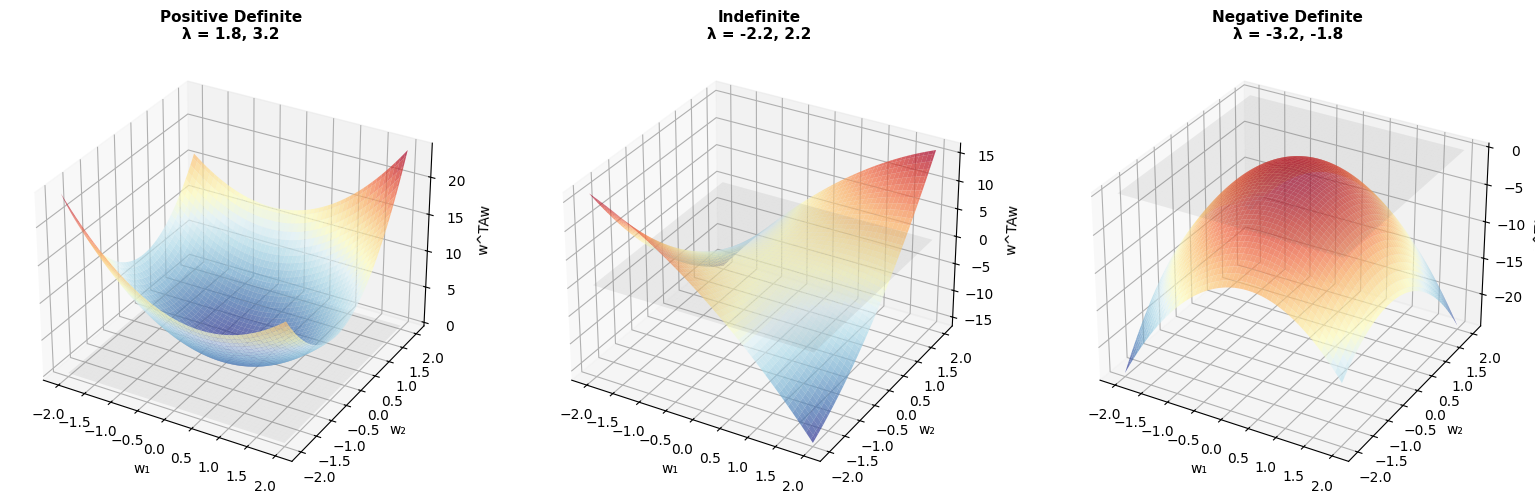

Quadratic form surfaces for three definiteness categories.
The gray plane shows z = 0. Positive definite is always above it;
negative definite is always below; indefinite crosses through it.


In [13]:

# Visualizing the quadratic form as a surface

fig, axes = plt.subplots(1, 3, figsize=(16, 5), subplot_kw={'projection': '3d'})

matrices = [
    (np.array([[2, 0.5], [0.5, 3]]), "Positive Definite\nλ = {:.1f}, {:.1f}"),
    (np.array([[-1, 2], [2, 1]]),   "Indefinite\nλ = {:.1f}, {:.1f}"),
    (np.array([[-3, -0.5], [-0.5, -2]]), "Negative Definite\nλ = {:.1f}, {:.1f}")
]

x = np.linspace(-2, 2, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

for ax, (A_mat, title_fmt) in zip(axes, matrices):
    Z = A_mat[0,0]*X**2 + (A_mat[0,1]+A_mat[1,0])*X*Y + A_mat[1,1]*Y**2
    ev = np.linalg.eig(A_mat)[0].real

    ax.plot_surface(X, Y, Z, cmap='RdYlBu_r', alpha=0.7, linewidth=0)
    ax.set_xlabel('w₁', fontsize=10)
    ax.set_ylabel('w₂', fontsize=10)
    ax.set_zlabel('w^TAw', fontsize=10)
    ax.set_title(title_fmt.format(ev[0], ev[1]), fontsize=11, fontweight='bold')

    # Add z=0 plane for reference
    ax.plot_surface(X, Y, np.zeros_like(X), alpha=0.1, color='gray')

plt.tight_layout()
plt.show()
print("Quadratic form surfaces for three definiteness categories.")
print("The gray plane shows z = 0. Positive definite is always above it;")
print("negative definite is always below; indefinite crosses through it.")

### Reading the Quadratic Form Surfaces

Each surface shows the value of $\mathbf{w}^T\mathbf{A}\mathbf{w}$ as a function of the two-element vector $\mathbf{w} = [w_1, w_2]^T$. The gray plane marks $z = 0$.

**Positive definite** (left): The surface forms an upward-opening bowl that never touches or crosses the gray plane (except at the origin where $\mathbf{w} = \mathbf{0}$). No matter which direction you move in the $(w_1, w_2)$ plane, the quadratic form is always positive. This is the "happy" case for optimization -- there is a clear, unique minimum.

**Indefinite** (center): The surface forms a **saddle shape** -- it curves upward in some directions and downward in others. The surface crosses the gray plane, meaning the quadratic form is positive for some vectors and negative for others. This is the "tricky" case for optimization -- gradient descent can get stuck at saddle points.

**Negative definite** (right): The surface forms a downward-opening bowl, always below the gray plane. The quadratic form is always negative. This is the maximum analog of positive definite.

**The eigenvalues determine the shape.** The eigenvectors define the axes of the bowl/saddle, and the eigenvalues determine the curvature along each axis. Larger $|\lambda|$ means tighter curvature (steeper surface).

---
## $\mathbf{A}^T\mathbf{A}$ Is Always Positive (Semi)Definite

One of the most important facts in applied linear algebra: any matrix of the form $\mathbf{S} = \mathbf{A}^T\mathbf{A}$ is guaranteed to be **positive semidefinite** (and positive definite if $\mathbf{A}$ has full column rank). Here is the proof:

$$\mathbf{w}^T \mathbf{S} \mathbf{w} = \mathbf{w}^T (\mathbf{A}^T\mathbf{A}) \mathbf{w} = (\mathbf{A}\mathbf{w})^T (\mathbf{A}\mathbf{w}) = \|\mathbf{A}\mathbf{w}\|^2 \geq 0$$

The squared norm $\|\mathbf{A}\mathbf{w}\|^2$ is always non-negative (magnitudes cannot be negative). It equals zero only when $\mathbf{A}\mathbf{w} = \mathbf{0}$, which happens only when $\mathbf{w}$ is in the null space of $\mathbf{A}$ (i.e., when $\mathbf{A}$ is singular).

**Why this matters enormously:**

Every **covariance matrix** is computed as $\mathbf{C} = \frac{1}{n-1}\mathbf{X}^T\mathbf{X}$ (where $\mathbf{X}$ is the mean-centered data matrix). Therefore, every covariance matrix is positive (semi)definite, which guarantees:

- All eigenvalues $\geq 0$ (variance is never negative!)
- All eigenvectors are real-valued
- All eigenvectors are orthogonal
- The eigendecomposition is numerically stable

In [14]:

# A^T @ A is always positive (semi)definite

np.random.seed(42)

# Test with various matrices of different shapes
test_cases = [
    ("Tall matrix (5x3)", np.random.randn(5, 3)),
    ("Wide matrix (3x5)", np.random.randn(3, 5)),
    ("Square matrix (4x4)", np.random.randn(4, 4)),
    ("Rank-deficient (5x3, rank 2)", None),  # special case
]

# Create rank-deficient matrix
R = np.random.randn(5, 2)
test_cases[3] = ("Rank-deficient (5x3, rank 2)", R @ np.random.randn(2, 3))

for name, A_mat in test_cases:
    S = A_mat.T @ A_mat
    evals_s = np.linalg.eigh(S)[0]  # eigh for symmetric

    all_nonneg = np.all(evals_s >= -1e-10)  # allow tiny numerical errors
    n_zero = np.sum(np.abs(evals_s) < 1e-10)

    category = "Positive DEFINITE" if n_zero == 0 else "Positive SEMIDEFINITE"

    print(f"{name}:")
    print(f"  A shape: {A_mat.shape}, rank: {np.linalg.matrix_rank(A_mat)}")
    print(f"  A^T A shape: {S.shape}")
    print(f"  Eigenvalues of A^T A: {evals_s.round(4)}")
    print(f"  All non-negative? {all_nonneg}")
    print(f"  Category: {category}")
    print()

Tall matrix (5x3):
  A shape: (5, 3), rank: 3
  A^T A shape: (3, 3)
  Eigenvalues of A^T A: [0.7939 5.3029 7.7416]
  All non-negative? True
  Category: Positive DEFINITE

Wide matrix (3x5):
  A shape: (3, 5), rank: 3
  A^T A shape: (5, 5)
  Eigenvalues of A^T A: [-0.      0.      0.544   3.016   7.1539]
  All non-negative? True
  Category: Positive SEMIDEFINITE

Square matrix (4x4):
  A shape: (4, 4), rank: 4
  A^T A shape: (4, 4)
  Eigenvalues of A^T A: [1.1992 2.5745 4.8594 7.5155]
  All non-negative? True
  Category: Positive DEFINITE

Rank-deficient (5x3, rank 2):
  A shape: (5, 3), rank: 2
  A^T A shape: (3, 3)
  Eigenvalues of A^T A: [-0.      0.6736  8.9164]
  All non-negative? True
  Category: Positive SEMIDEFINITE



### The Positive (Semi)Definite Guarantee

In every test case, the eigenvalues of $\mathbf{A}^T\mathbf{A}$ are non-negative -- confirming the proof. When $\mathbf{A}$ is full column-rank, all eigenvalues are strictly positive (positive definite). When $\mathbf{A}$ is rank-deficient, some eigenvalues are exactly zero (positive semidefinite).

**The connection to variance:** In PCA, the eigenvalues of the covariance matrix represent the variance captured by each principal component. A negative variance would be physically meaningless -- it would be like saying "the data varies by $-3$ units." The $\mathbf{A}^T\mathbf{A}$ structure ensures this never happens.

**Not all symmetric matrices are positive semidefinite.** The matrix $\begin{bmatrix} -1 & 0 \\ 0 & 2 \end{bmatrix}$ is symmetric but indefinite (one positive and one negative eigenvalue). It cannot be written as $\mathbf{A}^T\mathbf{A}$ for any real matrix $\mathbf{A}$.

---
## Generalized Eigendecomposition

Standard eigendecomposition solves $\mathbf{A}\mathbf{v} = \lambda\mathbf{v}$. **Generalized eigendecomposition** solves a more general problem:

$$\mathbf{A}\mathbf{v} = \lambda \mathbf{B} \mathbf{v}$$

Here, instead of scaling the eigenvector by a scalar ($\lambda\mathbf{v}$), we scale it by *another matrix* times a scalar ($\lambda\mathbf{B}\mathbf{v}$). The resulting $(\lambda, \mathbf{v})$ pairs are not eigenvectors of $\mathbf{A}$ alone or $\mathbf{B}$ alone -- they characterize the *relationship* between the two matrices.

Conceptually, you can think of generalized eigendecomposition as the regular eigendecomposition of the product $\mathbf{A}\mathbf{B}^{-1}$ (though the implementation does not require $\mathbf{B}$ to be invertible).

**Where is this used in data science?** Fisher's Linear Discriminant Analysis (LDA), a classification technique, finds the projection that maximizes the between-class variance relative to the within-class variance. This is formulated as a generalized eigendecomposition of two covariance matrices.

The standard requirement is that $\mathbf{B}$ is **positive (semi)definite** -- which is guaranteed when $\mathbf{B}$ is a covariance matrix.

In [15]:

# Generalized Eigendecomposition using SciPy

from scipy.linalg import eigh

np.random.seed(42)

# Create two symmetric positive definite matrices
R1 = np.random.randn(4, 4)
A = R1 @ R1.T           # SPD (symmetric positive definite)

R2 = np.random.randn(4, 4)
B = R2 @ R2.T + A / 10  # SPD (adding A/10 ensures well-conditioned)

print("Matrix A (symmetric, positive definite):")
print(A.round(2))
print(f"\nMatrix B (symmetric, positive definite):")
print(B.round(2))

# Generalized eigendecomposition: A @ v = lambda * B @ v
evals_gen, evecs_gen = eigh(A, B)

print(f"\nGeneralized eigenvalues: {evals_gen.round(4)}")
print(f"\nGeneralized eigenvectors (columns):")
print(evecs_gen.round(4))

# Verify: A @ v_i = lambda_i * B @ v_i for each pair
print("\n--- Verification ---")
for i in range(4):
    Av = A @ evecs_gen[:, i]
    lBv = evals_gen[i] * B @ evecs_gen[:, i]
    print(f"lambda_{i+1} = {evals_gen[i]:.4f}")
    print(f"  A@v    = {Av.round(4)}")
    print(f"  lam*B@v = {lBv.round(4)}")
    print(f"  Match? {np.allclose(Av, lBv)}")

# Note: for standard eigendecomposition, B = I
print("\n--- Connection to standard eigendecomposition ---")
evals_std, evecs_std = eigh(A, np.eye(4))
evals_direct = np.linalg.eigh(A)[0]
print(f"GED with B=I: {evals_std.round(4)}")
print(f"Standard eig:  {evals_direct.round(4)}")
print(f"Same? {np.allclose(sorted(evals_std), sorted(evals_direct))}")

Matrix A (symmetric, positive definite):
[[ 3.    2.11 -1.32 -1.59]
 [ 2.11  3.19 -1.11 -2.76]
 [-1.32 -1.11  0.95 -0.09]
 [-1.59 -2.76 -0.09  7.01]]

Matrix B (symmetric, positive definite):
[[ 4.24  0.61  0.97 -1.71]
 [ 0.61  4.55 -1.55 -3.77]
 [ 0.97 -1.55  1.87  1.67]
 [-1.71 -3.77  1.67  4.94]]

Generalized eigenvalues: [0.0481 0.4207 1.0569 9.0695]

Generalized eigenvectors (columns):
[[-0.2341  0.2274 -0.2801 -0.6301]
 [-0.1225 -0.6806 -0.0071 -0.4141]
 [-0.5429 -0.4702  0.1955  0.9992]
 [-0.1125 -0.1982  0.2425 -0.9806]]

--- Verification ---
lambda_1 = 0.0481
  A@v    = [-0.0674  0.0272 -0.0597 -0.029 ]
  lam*B@v = [-0.0674  0.0272 -0.0597 -0.029 ]
  Match? True
lambda_2 = 0.4207
  A@v    = [ 0.1836 -0.6251  0.0261  0.1726]
  lam*B@v = [ 0.1836 -0.6251  0.0261  0.1726]
  Match? True
lambda_3 = 1.0569
  A@v    = [-1.4995 -1.4997  0.54    2.1471]
  lam*B@v = [-1.4995 -1.4997  0.54    2.1471]
  Match? True
lambda_4 = 9.0695
  A@v    = [-2.5247 -1.0449  2.3227 -4.8191]
  lam*B@v =

### Generalized Eigendecomposition -- Key Points

The generalized eigenvalue equation $\mathbf{A}\mathbf{v} = \lambda\mathbf{B}\mathbf{v}$ reduces to the standard equation $\mathbf{A}\mathbf{v} = \lambda\mathbf{v}$ when $\mathbf{B} = \mathbf{I}$. So standard eigendecomposition is a special case.

**NumPy vs. SciPy:** `np.linalg.eig` does not support generalized eigendecomposition. Use `scipy.linalg.eigh` (for symmetric matrices -- the common case in data science) or `scipy.linalg.eig` (for general matrices).

**Input order matters:** In `scipy.linalg.eigh(A, B)`, the second matrix $\mathbf{B}$ is the one that conceptually gets inverted. Think of it as solving for the eigenvalues of $\mathbf{B}^{-1}\mathbf{A}$, even though the computation does not explicitly form the inverse.

We will see a practical application of generalized eigendecomposition in Chapter 15 when we study Fisher's Linear Discriminant Analysis for classification.

---
## Elegant Properties of Eigenvalues

Before we conclude, let us verify two beautiful mathematical relationships that connect eigenvalues to quantities we already know.

In [16]:

# Eigenvalue properties: trace and determinant

np.random.seed(42)

# Test with several random matrices
for trial in range(3):
    n = np.random.choice([3, 4, 5])
    A = np.random.randint(-5, 6, (n, n)).astype(float)
    evals = np.linalg.eig(A)[0]

    trace_A = np.trace(A)
    det_A = np.linalg.det(A)
    sum_evals = np.sum(evals).real
    prod_evals = np.prod(evals).real

    print(f"Trial {trial+1}: {n}x{n} matrix")
    print(f"  trace(A) = {trace_A:.4f},  sum(eigenvalues) = {sum_evals:.4f},  Match? {np.isclose(trace_A, sum_evals)}")
    print(f"  det(A)   = {det_A:.4f},  prod(eigenvalues) = {prod_evals:.4f},  Match? {np.isclose(det_A, prod_evals)}")
    print()

print("These are universal properties of ANY square matrix:")
print("  1) Sum of eigenvalues = trace of matrix")
print("  2) Product of eigenvalues = determinant of matrix")

Trial 1: 5x5 matrix
  trace(A) = -7.0000,  sum(eigenvalues) = -7.0000,  Match? True
  det(A)   = 1239.0000,  prod(eigenvalues) = 1239.0000,  Match? True

Trial 2: 4x4 matrix
  trace(A) = 0.0000,  sum(eigenvalues) = -0.0000,  Match? True
  det(A)   = 56.0000,  prod(eigenvalues) = 56.0000,  Match? True

Trial 3: 4x4 matrix
  trace(A) = 6.0000,  sum(eigenvalues) = 6.0000,  Match? True
  det(A)   = 629.0000,  prod(eigenvalues) = 629.0000,  Match? True

These are universal properties of ANY square matrix:
  1) Sum of eigenvalues = trace of matrix
  2) Product of eigenvalues = determinant of matrix


### Two Universal Eigenvalue Relationships

For **any** $M \times M$ square matrix (symmetric or not, singular or not, real or complex):

$$\sum_{i=1}^{M} \lambda_i = \text{trace}(\mathbf{A}) = \sum_{i=1}^{M} a_{ii}$$

$$\prod_{i=1}^{M} \lambda_i = \det(\mathbf{A})$$

The first equation says: the sum of eigenvalues equals the sum of diagonal elements. The second says: the product of eigenvalues equals the determinant. These are powerful sanity checks when implementing eigendecomposition in code.

**Corollary from the product rule:** If any eigenvalue is zero, the product is zero, so the determinant is zero, meaning the matrix is singular. This confirms our earlier observation that singular matrices have at least one zero eigenvalue.

---
## Summary

This chapter introduced eigendecomposition -- one of the most important topics in all of linear algebra for data science. Here is a consolidated summary of the key concepts.

**The Eigenvalue Equation:**

$$\mathbf{A}\mathbf{v} = \lambda\mathbf{v}$$

An eigenvector $\mathbf{v}$ is a direction that the matrix $\mathbf{A}$ stretches (or compresses, or flips) without rotating. The eigenvalue $\lambda$ is the stretching factor. Every $M \times M$ matrix has $M$ eigenvalue-eigenvector pairs.

**How to find them:**

$$\det(\mathbf{A} - \lambda\mathbf{I}) = 0 \;\;\text{(characteristic polynomial)} \;\;\longrightarrow\;\; \mathbf{v}_i \in \mathcal{N}(\mathbf{A} - \lambda_i\mathbf{I}) \;\;\text{(null space)}$$

**Diagonalization:**

$$\mathbf{A} = \mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^{-1}$$

Decomposes $\mathbf{A}$ into its eigenvectors ($\mathbf{V}$) and eigenvalues ($\boldsymbol{\Lambda}$). For symmetric matrices, $\mathbf{V}^{-1} = \mathbf{V}^T$.

**Symmetric matrices are special:**

| Property | Symmetric ($\mathbf{A} = \mathbf{A}^T$) | General |
|:---|:---|:---|
| Eigenvectors | Pairwise orthogonal | Linearly independent (if distinct $\lambda$) |
| Eigenvalues | Always real | Can be complex |
| Diagonalization | $\mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^T$ (no inverse needed) | $\mathbf{V}\boldsymbol{\Lambda}\mathbf{V}^{-1}$ (inverse required) |
| Python function | `np.linalg.eigh()` (faster, more stable) | `np.linalg.eig()` |

**Definiteness:** Determined by the signs of the eigenvalues. Positive (semi)definite matrices have all non-negative eigenvalues. Every covariance matrix ($\mathbf{A}^T\mathbf{A}$) is positive (semi)definite.

**Connections across the book:**

- **Chapter 4 (Null Space):** Eigenvectors live in the null space of the shifted matrix
- **Chapter 5 (Matrix Shifting):** $\mathbf{A} - \lambda\mathbf{I}$ is the key operation in finding eigenvalues
- **Chapter 6 (Rank):** Zero eigenvalues indicate rank deficiency
- **Chapter 8 (Determinants):** $\det(\mathbf{A} - \lambda\mathbf{I}) = 0$ yields the characteristic polynomial
- **Chapter 12 (Regularization):** Shifting eigenvalues away from zero stabilizes the matrix
- **Chapter 14 (SVD):** The SVD generalizes eigendecomposition to non-square matrices
- **Chapter 15 (Applications):** PCA, noise reduction, and classification use eigendecomposition directly